# DCC

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train=tf.keras.utils.normalize(x_train, axis=1)  #convert all the values between 0 and 1-> easier for the system to calculate
x_test=tf.keras.utils.normalize(x_test, axis=1)

I0000 00:00:1782930720.152955  449497 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782930720.186478  449497 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782930721.154145  449497 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# DNN Base function

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

def mnist_dnn(num_of_layers, sum_of_neurons, num_of_epochs, with_diagrams=True, with_dropout=False):
    model_topology = [
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten()
    ]

    model_topology += [tf.keras.layers.Dense(sum_of_neurons, activation='relu', name=f"features{i}") for i in range(num_of_layers)]

    if(with_dropout):
        model_topology += [tf.keras.layers.Dropout(0.3)] # Idee von CLaude, da 99 % so nicht möglich waren

    model_topology += [tf.keras.layers.Dense(10, activation='softmax')]

    model_test=tf.keras.Sequential(model_topology)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model_test.fit(
        x_train,
        y_train,
        epochs=num_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    )

    if(with_diagrams):
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Test Accuracy')

        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
        plt.legend()
        plt.show()

    return model_test, history

### 1 hidden layer: 8 neurons

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step - accuracy: 0.8185 - loss: 0.6567 - val_accuracy: 0.9025 - val_loss: 0.3561
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.9031 - loss: 0.3379 - val_accuracy: 0.9138 - val_loss: 0.3074
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.9119 - loss: 0.3060 - val_accuracy: 0.9175 - val_loss: 0.2954
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 548us/step - accuracy: 0.9167 - loss: 0.2906 - val_accuracy: 0.9182 - val_loss: 0.2908
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.9194 - loss: 0.2809 - val_accuracy: 0.9181 - val_loss: 0.2887


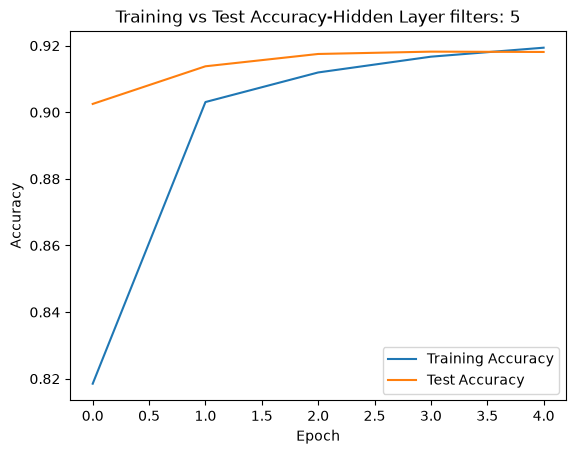

(<Sequential name=sequential_2, built=True>,
 <keras.src.callbacks.history.History at 0x78ce6032d390>)

In [10]:
mnist_dnn(1, 8, 5)

### 2 hidden layers: 4 for each

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.5851 - loss: 1.2318 - val_accuracy: 0.7757 - val_loss: 0.7652
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.7981 - loss: 0.6855 - val_accuracy: 0.8210 - val_loss: 0.6193
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - accuracy: 0.8227 - loss: 0.6025 - val_accuracy: 0.8301 - val_loss: 0.5810
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.8332 - loss: 0.5698 - val_accuracy: 0.8260 - val_loss: 0.5730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 557us/step - accuracy: 0.8398 - loss: 0.5492 - val_accuracy: 0.8446 - val_loss: 0.5449


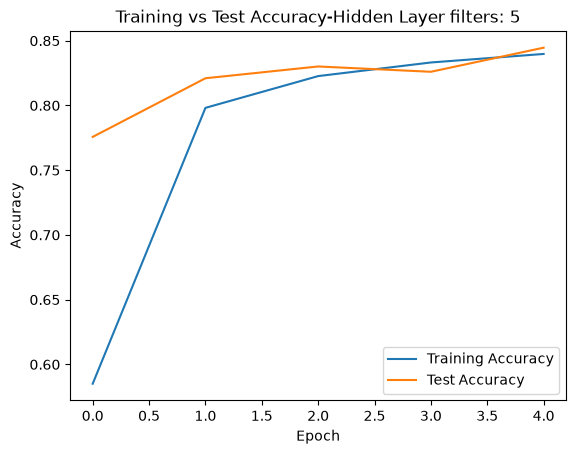

(<Sequential name=sequential_3, built=True>,
 <keras.src.callbacks.history.History at 0x78ce6016a790>)

In [11]:
mnist_dnn(2, 4, 5)

# Test accuracy

In [4]:
def test_accuracy(max_iterations, epochs_per_iteration, accuracy_threshold, eval_fn=mnist_dnn, iteration_start=0, with_diagrams=True, with_dropout=False):
    accuracy = 0
    i = iteration_start

    accuracy_history = []
    weights_history = []

    while(accuracy < accuracy_threshold and i <= max_iterations):
        model, history = eval_fn(1, i, epochs_per_iteration, False, with_dropout)

        trainable_weights = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights) # Claude

        accuracy = history.history['val_accuracy'][-1:][0]
        print(f"Iteration {i}: Accuracy = {accuracy} Weights = {trainable_weights}")

        accuracy_history.append(accuracy)
        weights_history.append(trainable_weights)
        i += 1

    if(with_diagrams):
        plt.plot(weights_history, accuracy_history, label='Training Accuracy')

        plt.xlabel('Weights')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.show()

# 98 % Accuracy

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 874us/step - accuracy: 0.9230 - loss: 0.2662 - val_accuracy: 0.9587 - val_loss: 0.1450
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - accuracy: 0.9652 - loss: 0.1162 - val_accuracy: 0.9692 - val_loss: 0.1003
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - accuracy: 0.9758 - loss: 0.0802 - val_accuracy: 0.9714 - val_loss: 0.0904
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - accuracy: 0.9819 - loss: 0.0587 - val_accuracy: 0.9759 - val_loss: 0.0759
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - accuracy: 0.9851 - loss: 0.0466 - val_accuracy: 0.9777 - val_loss: 0.0781
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - accuracy: 0.9885 - loss: 0.0369 - val_accuracy: 0.9787 - val_loss: 0.0705
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - accuracy: 0.9910 - loss: 0.0297 - val_accuracy: 0.9776 - val_loss: 0.0768
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 833us/step - accuracy: 0.9923 -

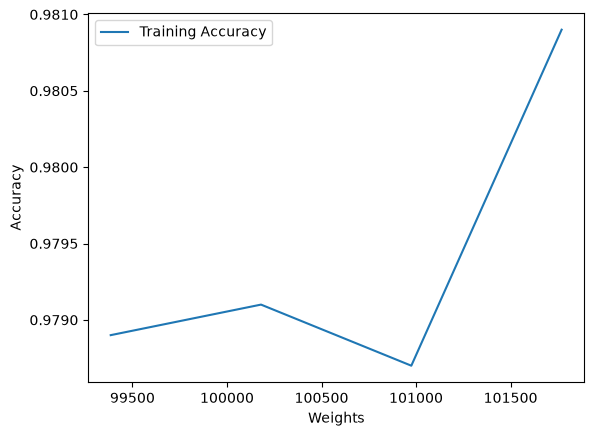

In [34]:
test_accuracy(140, 15, 0.98, iteration_start=125)

In Neuronen:

Bei 15 Epochen:
98 % erreicht bei ~ 128 Neuronen

In Weights:
98 % erreicht bei ~ 101770 Weights

# 99 % Accuracy

In [129]:
test_accuracy(1030, 120, 0.99, iteration_start=220, with_dropout=True)

Epoch 1/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9192 - loss: 0.2777 - val_accuracy: 0.9616 - val_loss: 0.1297
Epoch 2/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9602 - loss: 0.1345 - val_accuracy: 0.9674 - val_loss: 0.1099
Epoch 3/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9689 - loss: 0.1005 - val_accuracy: 0.9758 - val_loss: 0.0776
Epoch 4/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9739 - loss: 0.0823 - val_accuracy: 0.9778 - val_loss: 0.0692
Epoch 5/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9772 - loss: 0.0713 - val_accuracy: 0.9770 - val_loss: 0.0692
Epoch 6/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9801 - loss: 0.0625 - val_accuracy: 0.9785 - val_loss: 0.0694
Epoch 7/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9824 - loss: 0.0552 - val_accuracy: 0.9803 - val_loss: 0.0626
Epoch 8/120
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9840 - loss: 0

KeyboardInterrupt: 

99 % waren exakt nicht zu erreichgen. Auch nicht mit verschiedenen Kombinationen von Hidden Layers oder Dropout.

Schluss war bei ca. 98,5 %.

## Accuracy über 10 Trainingsdurchläufe

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 807us/step - accuracy: 0.9127 - loss: 0.3150 - val_accuracy: 0.9459 - val_loss: 0.1867
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step - accuracy: 0.9583 - loss: 0.1417 - val_accuracy: 0.9624 - val_loss: 0.1255
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - accuracy: 0.9715 - loss: 0.0968 - val_accuracy: 0.9670 - val_loss: 0.1069
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.9782 - loss: 0.0722 - val_accuracy: 0.9713 - val_loss: 0.0949
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.9832 - loss: 0.0568 - val_accuracy: 0.9736 - val_loss: 0.0841
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.9866 - loss: 0.0445 - val_accuracy: 0.9759 - val_loss: 0.0815
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step - accuracy: 0.9899 - loss: 0.0357 - val_accuracy: 0.9740 - val_loss: 0.0892
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.9923 -

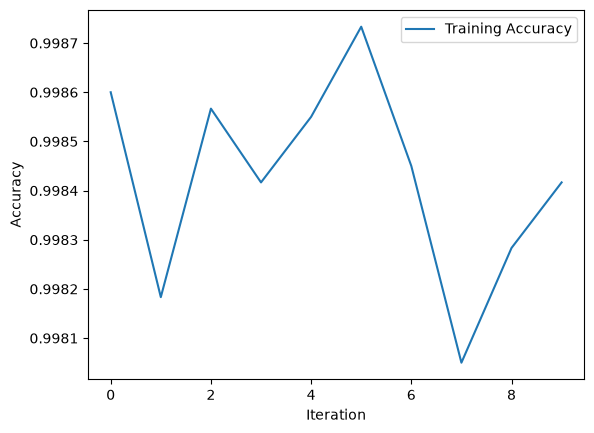

In [6]:
accuracy_history = []

for i in range(10):
    model, history = mnist_dnn(1, 128, 15, False)
    accuracy = history.history['accuracy'][-1:][0]

    accuracy_history.append(accuracy)

plt.plot(accuracy_history, label='Training Accuracy')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# CNN

In [8]:
def mnist_cnn(_, num_filters, num_of_epochs, with_diagrams=True, with_dropout=False):
    model_topology = [
        # Idee von Claude
        tf.keras.layers.Input(shape=(28, 28, 1)),                       # Eingabeform
        tf.keras.layers.Conv2D(num_filters, (3, 3), activation='relu'), # Erste Faltungsschicht
        tf.keras.layers.MaxPooling2D((2, 2)),                           # Reduzuert die Größe der Matrix aus jeder 2 x 2 Submatrix wird nur der größte Wert behalten

        # Zweite Schicht, da mit einer 99 % Accuracy nicht erreicht werden konnten
        # Idee von Claude
        tf.keras.layers.Conv2D(num_filters, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.25), # Setzt Nauronen während des Trainings aus, damit kein Overfitting passiert
        tf.keras.layers.Dense(10, activation='softmax')
    ]

    model_test=tf.keras.Sequential(model_topology)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model_test.fit(
        x_train.reshape(-1, 28, 28, 1),
        y_train,
        epochs=num_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    )

    if(with_diagrams):
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Test Accuracy')

        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
        plt.legend()
        plt.show()

    return model_test, history

# 98 % Accuracy

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8138 - loss: 0.5730 - val_accuracy: 0.9498 - val_loss: 0.1702
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9252 - loss: 0.2398 - val_accuracy: 0.9635 - val_loss: 0.1260
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9356 - loss: 0.2046 - val_accuracy: 0.9668 - val_loss: 0.1118
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9423 - loss: 0.1848 - val_accuracy: 0.9699 - val_loss: 0.1001
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9468 - loss: 0.1736 - val_accuracy: 0.9725 - val_loss: 0.0954
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9497 - loss: 0.1629 - val_accuracy: 0.9745 - val_loss: 0.0882
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9511 - loss: 0.1573 - val_accuracy: 0.9738 - val_loss: 0.0857
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9519 - loss: 0.1519 - 

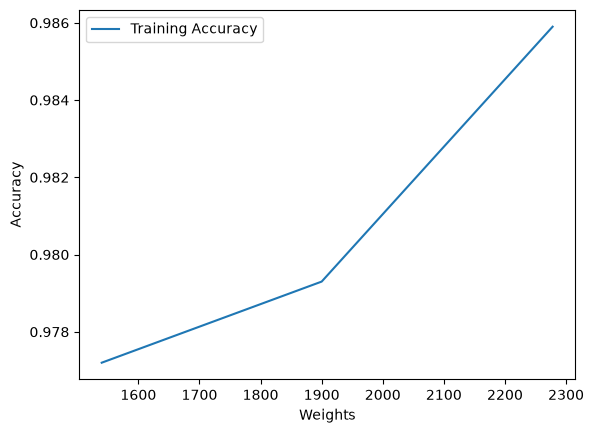

In [91]:
test_accuracy(55, 10, 0.98, iteration_start=5, eval_fn=mnist_cnn)

98 % Accuracy bei ~ 2278 Gewichten

# 99 % Accuracy

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8589 - loss: 0.4491 - val_accuracy: 0.9596 - val_loss: 0.1370
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9453 - loss: 0.1787 - val_accuracy: 0.9713 - val_loss: 0.0971
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9550 - loss: 0.1488 - val_accuracy: 0.9744 - val_loss: 0.0861
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9591 - loss: 0.1335 - val_accuracy: 0.9782 - val_loss: 0.0731
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9610 - loss: 0.1260 - val_accuracy: 0.9804 - val_loss: 0.0658
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9648 - loss: 0.1146 - val_accuracy: 0.9811 - val_loss: 0.0604
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9651 - loss: 0.1117 - val_accuracy: 0.9799 - val_loss: 0.0627
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9661 - loss: 0.1080 - 

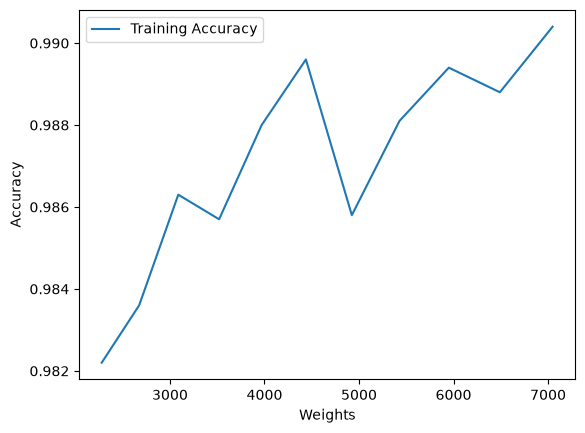

In [92]:
test_accuracy(32, 10, 0.99, iteration_start=15, eval_fn=mnist_cnn)

98 % Accuracy bei ~ 7048 Gewichten

## Accuracy über 10 Trainingsdurchläufe


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9022 - loss: 0.3226 - val_accuracy: 0.9684 - val_loss: 0.1045
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9600 - loss: 0.1326 - val_accuracy: 0.9733 - val_loss: 0.0822
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9673 - loss: 0.1056 - val_accuracy: 0.9796 - val_loss: 0.0654
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9712 - loss: 0.0937 - val_accuracy: 0.9815 - val_loss: 0.0593
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9744 - loss: 0.0840 - val_accuracy: 0.9830 - val_loss: 0.0532
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9759 - loss: 0.0775 - val_accuracy: 0.9836 - val_loss: 0.0498
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9777 - loss: 0.0720 - val_accuracy: 0.9824 - val_loss: 0.0558
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9787 - loss: 0.0674 - 

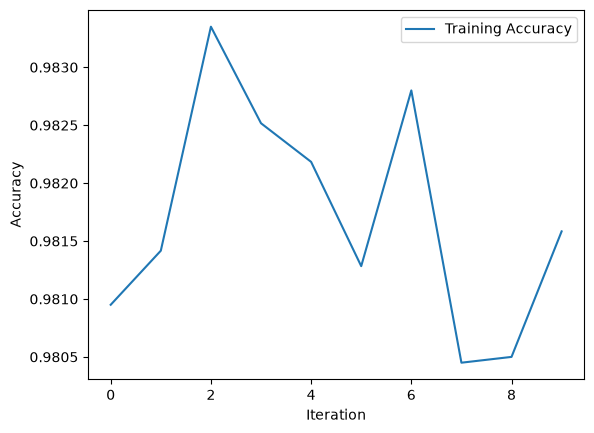

In [9]:
accuracy_history = []

for i in range(10):
    model, history = mnist_cnn(1, 17, 10, False)
    accuracy = history.history['accuracy'][-1:][0]

    accuracy_history.append(accuracy)

plt.plot(accuracy_history, label='Training Accuracy')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

y:  5


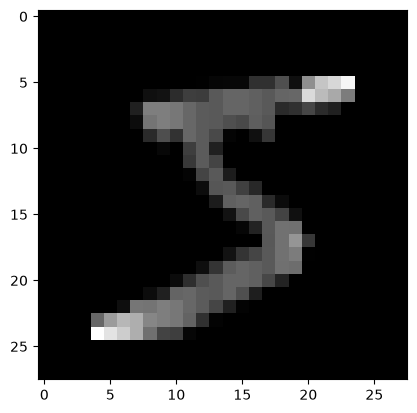

In [50]:
plt.imshow(x_train[0], cmap='gray')
print("y: ",y_train[0])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.9016 - loss: 0.3582 - val_accuracy: 0.9365 - val_loss: 0.2126
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - accuracy: 0.9483 - loss: 0.1787 - val_accuracy: 0.9539 - val_loss: 0.1523
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - accuracy: 0.9622 - loss: 0.1300 - val_accuracy: 0.9608 - val_loss: 0.1312
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - accuracy: 0.9699 - loss: 0.1019 - val_accuracy: 0.9668 - val_loss: 0.1126
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.9759 - loss: 0.0820 - val_accuracy: 0.9693 - val_loss: 0.1062
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - accuracy: 0.9797 - loss: 0.0683 - val_accuracy: 0.9704 - val_loss: 0.0975
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step - accuracy: 0.9835 - loss: 0.0568 - val_accuracy: 0.9713 - val_loss: 0.0995
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - accuracy: 0.9852 -

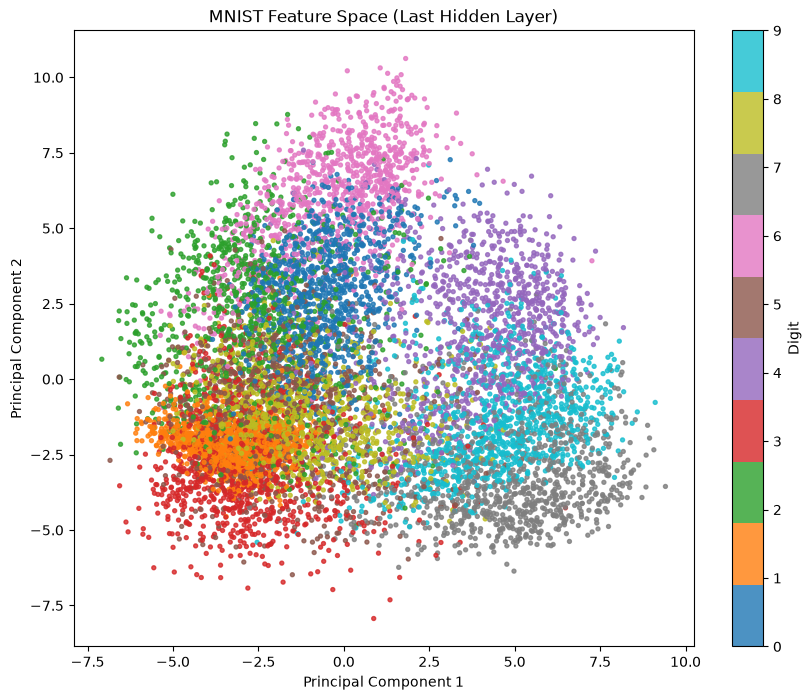

In [53]:
from sklearn.decomposition import PCA

model, history = mnist_dnn(1, 71, 10, False)
# ----------------------------
# Evaluate
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

# ----------------------------
# Create a model that outputs the last hidden layer
# ----------------------------
#model.build((None, 28, 28))

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("features").output
)

# Extract 128-dimensional features
features = feature_model.predict(x_test)

print("Feature shape:", features.shape)
# (10000, 128)

# ----------------------------
# Reduce to 2 dimensions using PCA
# ----------------------------
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.title("MNIST Feature Space (Last Hidden Layer)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

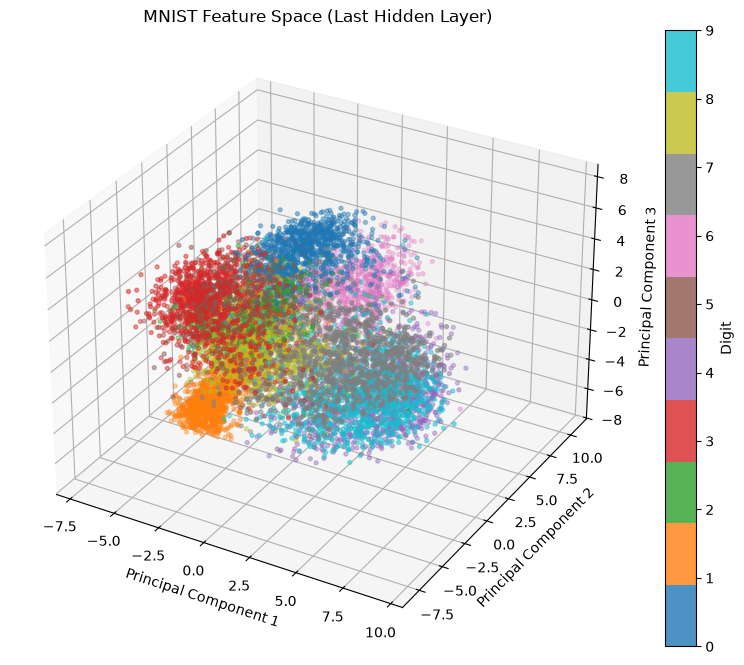

In [54]:
from mpl_toolkits.mplot3d import Axes3D  # Optional in newer Matplotlib versions

# ----------------------------
# Reduce to 3 dimensions using PCA
# ----------------------------
pca3d = PCA(n_components=3)
features_3d = pca3d.fit_transform(features)

# ----------------------------
# Create a 3D figure
# ----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    features_3d[:, 0],   # x
    features_3d[:, 1],   # y
    features_3d[:, 2],   # z
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

fig.colorbar(scatter, ticks=range(10), label="Digit")

ax.set_title("MNIST Feature Space (Last Hidden Layer)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.show()

Wie gut hat das Modell gelernt?

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step


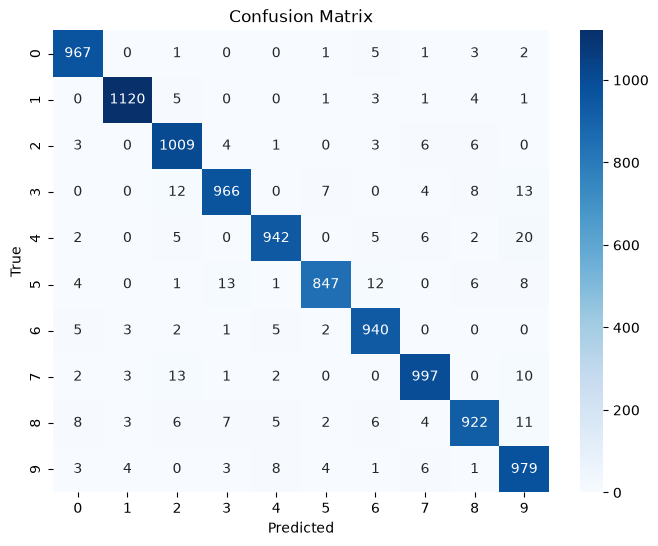

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Wie gut erkannt das Modell (DNN) Ziffern?

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.97      0.96      0.96      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.95      0.96       892
           6       0.96      0.98      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.94      0.97      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

